This notebook contains the computational analysis for The Right Word Assessment 2.

Author: 25000148897

The notebook implements the following workflow:
1. corpus loading
2. text cleaning
3. feature extraction
4. statistical comparison
5. visualization

In [1]:
# ============================================================
# CELL 1: SETUP
# Purpose:
# - install required packages
# - mount Google Drive
# - make the notebook reproducible in Google Colab
#
# This cell prepares the runtime environment. If the session is
# restarted, this cell should be run again before any others.
# ============================================================

!pip install pdfminer.six langdetect scipy lexicalrichness language_tool_python transformers torch seaborn

from google.colab import drive
drive.mount('/content/drive')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 1.8 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=461f50f55e409c637dc0585d261d6cf161278e8db4d9211c9e84e939124e04ea
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
  Created wheel for lexicalrichness: filename=lexicalrichness-0.5.1-py3-none-any.whl size=15418 sha256=40ec8bec5da9680140a1baa6aa15b3b01ad53b02589f7744ec4d12f5d583cf3f
  Stored in directory: /root/.cache/pip/wheels/eb/40/d0/053edb84485f223effdbf0f91fc2b6ec6fc6cf2230aadca09a
Successfully built langdetect lexicalrichness
Mounted at /con

In [2]:
# ============================================================
# CELL 2: IMPORTS AND PROJECT SETTINGS
# Purpose:
# - import all required libraries
# - define corpus locations and plotting defaults
#
# Keeping imports and project settings in one place makes the
# notebook easier to inspect and rerun from scratch.
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pdfminer.high_level import extract_text
from langdetect import detect
from scipy.stats import ttest_ind
from lexicalrichness import LexicalRichness
import language_tool_python

import torch
from transformers import GPT2TokenizerFast, GPT2LMHeadModel

plt.rcParams["figure.dpi"] = 120
sns.set_style("whitegrid")

# Corpus folders in Google Drive
FOLDERS = {
    "pre_LLM": "/content/drive/MyDrive/papers/pre_LLM",
    "declared_LLM": "/content/drive/MyDrive/papers/declared_LLM",
    "post_LLM": "/content/drive/MyDrive/papers/post_LLM"
}

# House colours agreed for the three groups
GROUP_LABELS = {
    "pre_LLM": "Pre-LLM",
    "declared_LLM": "Declared-LLM",
    "post_LLM": "Post-LLM"
}

GROUP_ORDER = ["pre_LLM", "declared_LLM", "post_LLM"]
LABEL_ORDER = ["Pre-LLM", "Declared-LLM", "Post-LLM"]

GROUP_PALETTE = {
    "Pre-LLM": "#1f77b4",       # blue
    "Declared-LLM": "#2ca02c",  # green
    "Post-LLM": "#ff7f0e"       # orange
}

# Limit surprisal calculation for runtime practicality
MAX_GPT_TOKENS = 800

# Minimum extracted word count to keep a paper in the analysis
MIN_WORDS = 1500

In [3]:
# ============================================================
# CELL 3: HELPER FUNCTIONS
# Purpose:
# - define reusable functions for metadata extraction, cleaning
#   and descriptive metrics
#
# This cell contains the operational definitions used throughout
# the notebook, including text cleaning and lexical metrics.
# ============================================================

def infer_year_from_filename(filename):
    """
    Attempt to detect a 4-digit year from a filename.
    Example: '2019 article title.pdf' -> 2019
    """
    match = re.search(r"(19|20)\d{2}", str(filename))
    return int(match.group()) if match else None


def detect_language_safe(text):
    """
    Detect language safely using only the first part of the text.
    This helps exclude non-English articles from the analysis.
    """
    try:
        return detect(str(text)[:5000])
    except:
        return "unknown"


def detect_llm_mention(text):
    """
    Detect explicit mentions of LLM tools in the text.
    """
    text = str(text).lower()
    patterns = [
        r"chatgpt",
        r"gpt[- ]?4",
        r"gpt[- ]?3",
        r"large language model",
        r"\bllm\b",
        r"openai"
    ]
    return any(re.search(p, text) for p in patterns)


def extract_reference_section(text):
    """
    Attempt to isolate the references or bibliography section.
    """
    text = str(text)
    match = re.search(r"(?is)\b(references|bibliography)\b(.*)$", text)
    if match:
        return match.group(2).strip()
    return ""


def estimate_reference_entries(reference_text):
    """
    Estimate the number of bibliography entries from the extracted
    reference section. This is approximate because PDF extraction
    varies in quality across publishers.
    """
    lines = str(reference_text).split("\n")
    ref_lines = []

    for line in lines:
        line = line.strip()
        if re.match(r"^[A-Z][A-Za-z\-]+,\s*[A-Z]", line):
            ref_lines.append(line)

    return len(ref_lines)


def clean_article_text(text):
    """
    Remove sections that would distort stylistic analysis:
    - abstract
    - figure captions
    - table captions
    - acknowledgements
    - references / bibliography
    """
    text = str(text)

    text = re.sub(r"(?is)\babstract\b.*?(?=\bintroduction\b|\bbackground\b)", " ", text)
    text = re.sub(r"(?is)\bfigure\s+\d+[^.\n]*[.\n]", " ", text)
    text = re.sub(r"(?is)\btable\s+\d+[^.\n]*[.\n]", " ", text)
    text = re.sub(r"(?is)\backnowledg(e)?ments\b.*?(?=\breferences\b|\bbibliography\b|$)", " ", text)
    text = re.sub(r"(?is)\b(references|bibliography)\b.*$", " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text


def sentence_lengths(text):
    """
    Approximate sentence lengths using punctuation splitting.
    """
    sentences = re.split(r"[.!?]+", str(text))
    return [len(s.split()) for s in sentences if len(s.split()) > 0]


def burstiness(lengths):
    """
    Sentence-length variation, operationalised as the standard
    deviation of sentence lengths within a document.
    """
    return float(np.std(lengths)) if len(lengths) > 1 else 0.0


def lexical_diversity_mtld(text):
    """
    MTLD lexical diversity score.
    """
    try:
        lex = LexicalRichness(str(text))
        return float(lex.mtld(threshold=0.72))
    except:
        return np.nan


def cohen_d(group1, group2):
    """
    Effect size for independent groups.
    """
    g1 = np.array(group1, dtype=float)
    g2 = np.array(group2, dtype=float)

    pooled_sd = np.sqrt((g1.std(ddof=1)**2 + g2.std(ddof=1)**2) / 2)
    if pooled_sd == 0:
        return 0.0
    return (g2.mean() - g1.mean()) / pooled_sd


def remove_outliers_iqr(df, column):
    """
    Return a dataframe with IQR outliers removed for one column.
    Used for plotting only, not for statistical tests.
    """
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[(df[column] >= lower) & (df[column] <= upper)]

In [4]:
# ============================================================
# CELL 4: LOAD PDF CORPUS
# Purpose:
# - read the PDF files from Google Drive
# - extract text
# - build the master dataframe df_all
#
# The corpus is divided into three groups:
# pre_LLM, declared_LLM and post_LLM.
# ============================================================

records = []

for group, folder in FOLDERS.items():
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        continue

    files = [f for f in os.listdir(folder) if f.lower().endswith(".pdf")]
    print(f"{group}: {len(files)} pdf files found")

    for i, filename in enumerate(files, start=1):
        path = os.path.join(folder, filename)

        try:
            text = extract_text(path)

            records.append({
                "file": filename,
                "corpus_group": group,
                "year": infer_year_from_filename(filename),
                "pdf_path": path,
                "main_text": text
            })

            if i % 10 == 0:
                print(f"  processed {i} files from {group}")

        except Exception as e:
            print(f"Extraction failed for {filename}: {e}")

df_all = pd.DataFrame(records)

print("\nPapers loaded:", len(df_all))
print(df_all[["file", "corpus_group", "year"]].head())

pre_LLM: 30 pdf files found
  processed 10 files from pre_LLM
  processed 20 files from pre_LLM
  processed 30 files from pre_LLM
declared_LLM: 10 pdf files found
  processed 10 files from declared_LLM
post_LLM: 30 pdf files found
  processed 10 files from post_LLM
  processed 20 files from post_LLM
  processed 30 files from post_LLM

Papers loaded: 70
                                            file corpus_group  year
0                2022 Lit and Psych Ayesha P.pdf      pre_LLM  2022
1  2019 Management of depression Frost et al.pdf      pre_LLM  2019
2          2018 The Big Five Frost and Mehta.pdf      pre_LLM  2018
3         2019 Entrepreurship learning Hasan.pdf      pre_LLM  2019
4        2022 Positive Psychology Derahkshan.pdf      pre_LLM  2022


In [5]:
# ============================================================
# CELL 5: DIAGNOSTICS, LANGUAGE FILTERING AND CLEANING
# Purpose:
# - inspect extraction quality
# - remove non-English papers
# - detect LLM mentions
# - estimate references
# - create clean_text and word_count
# - remove papers with too little extractable text
#
# The minimum-length filter removes papers whose PDFs contain
# too little machine-readable prose (for example figure-heavy
# articles), which would otherwise distort word-normalized
# metrics.
# ============================================================

df_all["main_text"] = df_all["main_text"].fillna("").astype(str)
df_all["raw_word_count"] = df_all["main_text"].apply(lambda x: len(x.split()))

print("Average raw word count:", round(df_all["raw_word_count"].mean(), 1))
print("Median raw word count:", round(df_all["raw_word_count"].median(), 1))
print("\nSample extracted text:\n")
print(df_all["main_text"].iloc[0][:1000])

df_all["language"] = df_all["main_text"].apply(detect_language_safe)
print("\nLanguage counts before filtering:")
print(df_all["language"].value_counts())

df_all = df_all[df_all["language"] == "en"].copy()

df_all["llm_mentioned"] = df_all["main_text"].apply(detect_llm_mention)
df_all["reference_section"] = df_all["main_text"].apply(extract_reference_section)
df_all["reference_count_est"] = df_all["reference_section"].apply(estimate_reference_entries)

df_all["clean_text"] = df_all["main_text"].apply(clean_article_text)
df_all["word_count"] = df_all["clean_text"].apply(lambda x: len(x.split()))

print("\nAfter English-only filtering:")
print("Papers remaining:", len(df_all))
print("Average cleaned word count:", round(df_all["word_count"].mean(), 1))
print("Median cleaned word count:", round(df_all["word_count"].median(), 1))
print("LLM mentions detected:", int(df_all["llm_mentioned"].sum()))

df_all = df_all[df_all["word_count"] >= MIN_WORDS].copy()

print("\nAfter minimum-length filter:")
print("Papers remaining:", len(df_all))

Average raw word count: 7229.4
Median raw word count: 6525.0

Sample extracted text:

International Journal of Applied Research in Social Sciences, Volume 4, Issue 8, October 2022 

OPEN ACCESS 

International Journal of Applied Research in Social Sciences 
P-ISSN: 2706-9176, E-ISSN: 2706-9184  
Volume 4, Issue 8, P.No. 284-292, October 2022 
DOI: 10.51594/ijarss.v4i8.382 
Fair East Publishers 
Journal Homepage: www.fepbl.com/index.php/ijarss 

ON THE RELATIONSHIP BETWEEN LITERATURE AND 
PSYCHOLOGY 

Ayesha Dar1 

1MA English (Linguistics & Literature),  
National University of Modern Languages, Islamabad, Pakistan 
______________________________________________________________________________ 
*Corresponding Author: Ayesha Dar  
Corresponding Author Email:  ayesha.dar5815@gmail.com  
Article Received: 01-09-22 

            Published: 06-10-22 

     Accepted: 01-10-22   

Commons 

Licensing Details: Author retains the right of this article. The article is distributed under the terms

In [6]:
# ============================================================
# CELL 6: INITIALIZE LANGUAGE TOOLS AND GPT-2
# Purpose:
# - create UK and US English grammar/spelling tools
# - load GPT-2 for surprisal estimation
#
# The grammar checker is used in a conservative way: only
# overlaps between UK and US variants are counted as robust
# misspellings/grammar issues.
# ============================================================

tool_gb = language_tool_python.LanguageTool("en-GB")
tool_us = language_tool_python.LanguageTool("en-US")

tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("LanguageTool checkers ready.")
print("GPT-2 loaded on device:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

LanguageTool checkers ready.
GPT-2 loaded on device: cpu


In [7]:
# ============================================================
# CELL 7: ADVANCED FEATURE FUNCTIONS
# Purpose:
# - define grammar/spelling counting functions
# - define surprisal / perplexity calculations
# ============================================================

def spelling_matches(tool, text):
    matches = tool.check(text)
    spelling = []

    exclude_markers = ["COMPOUND", "COMPOUNDS", "HYPHEN", "DASH"]

    for match in matches:
        issue_type = str(getattr(match, "rule_issue_type", "")).lower()
        rule_id = str(getattr(match, "rule_id", "")).upper()
        offset = getattr(match, "offset", None)
        length = getattr(match, "error_length", None)

        if issue_type == "misspelling" and not any(marker in rule_id for marker in exclude_markers):
            spelling.append((offset, length))

    return set(spelling)


def misspelling_count_both_variants(text):
    gb = spelling_matches(tool_gb, text)
    us = spelling_matches(tool_us, text)
    return len(gb.intersection(us))


def grammar_matches(tool, text):
    matches = tool.check(text)
    grammar = []

    for match in matches:
        issue_type = str(getattr(match, "rule_issue_type", "")).lower()
        offset = getattr(match, "offset", None)
        length = getattr(match, "error_length", None)

        if issue_type != "misspelling":
            grammar.append((offset, length))

    return set(grammar)


def grammar_count_both_variants(text):
    gb = grammar_matches(tool_gb, text)
    us = grammar_matches(tool_us, text)
    return len(gb.intersection(us))


def surprisal_metrics(text, max_tokens=MAX_GPT_TOKENS):
    """
    Compute:
    - mean_surprisal
    - surprisal_variance
    - perplexity
    over the first max_tokens tokens.
    """
    text = str(text)
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_tokens)
    input_ids = enc["input_ids"].to(device)

    if input_ids.shape[1] < 2:
        return pd.Series({
            "mean_surprisal": np.nan,
            "surprisal_variance": np.nan,
            "perplexity": np.nan
        })

    with torch.no_grad():
        outputs = model(input_ids)
        logits = outputs.logits

    shift_logits = logits[:, :-1, :]
    shift_labels = input_ids[:, 1:]

    log_probs = torch.nn.functional.log_softmax(shift_logits, dim=-1)
    token_log_probs = log_probs.gather(2, shift_labels.unsqueeze(-1)).squeeze(-1)
    token_surprisals = -token_log_probs.squeeze(0).cpu().numpy()

    mean_surprisal = float(np.mean(token_surprisals))
    surprisal_variance = float(np.var(token_surprisals))
    perplexity = float(np.exp(mean_surprisal))

    return pd.Series({
        "mean_surprisal": mean_surprisal,
        "surprisal_variance": surprisal_variance,
        "perplexity": perplexity
    })

In [8]:
# ============================================================
# CELL 8: FEATURE EXTRACTION
# Purpose:
# - compute all stylistic variables used in the study
#
# This is the main analytical cell. It converts cleaned text into
# measurable variables for later statistical and visual comparison.
# ============================================================

df_all["sentence_lengths"] = df_all["clean_text"].apply(sentence_lengths)
df_all["sentence_count"] = df_all["sentence_lengths"].apply(len)
df_all["burstiness"] = df_all["sentence_lengths"].apply(burstiness)

df_all["references_per_1000_words"] = df_all.apply(
    lambda row: (row["reference_count_est"] / row["word_count"] * 1000) if row["word_count"] > 0 else 0,
    axis=1
)

df_all["lexical_diversity_mtld"] = df_all["clean_text"].apply(lexical_diversity_mtld)

print("Running grammar/spelling checks...")
df_all["grammar_error_count"] = df_all["clean_text"].apply(grammar_count_both_variants)
df_all["misspelling_count"] = df_all["clean_text"].apply(misspelling_count_both_variants)

df_all["grammar_errors_per_1000"] = df_all.apply(
    lambda row: (row["grammar_error_count"] / row["word_count"] * 1000) if row["word_count"] > 0 else 0,
    axis=1
)
df_all["misspellings_per_1000"] = df_all.apply(
    lambda row: (row["misspelling_count"] / row["word_count"] * 1000) if row["word_count"] > 0 else 0,
    axis=1
)

print("Running surprisal/perplexity calculations...")
surprisal_df = df_all["clean_text"].apply(surprisal_metrics)
df_all = pd.concat([df_all, surprisal_df], axis=1)

# Remove extreme grammar artefacts from that metric only
MAX_GRAMMAR_RATE = 200
df_all.loc[df_all["grammar_errors_per_1000"] > MAX_GRAMMAR_RATE, "grammar_errors_per_1000"] = np.nan

print(df_all[[
    "file",
    "corpus_group",
    "word_count",
    "burstiness",
    "reference_count_est",
    "references_per_1000_words",
    "lexical_diversity_mtld",
    "grammar_errors_per_1000",
    "misspellings_per_1000",
    "mean_surprisal",
    "surprisal_variance",
    "perplexity"
]].head())

Running grammar/spelling checks...
Running surprisal/perplexity calculations...
                                            file corpus_group  word_count  \
0                2022 Lit and Psych Ayesha P.pdf      pre_LLM        3627   
1  2019 Management of depression Frost et al.pdf      pre_LLM        6016   
2          2018 The Big Five Frost and Mehta.pdf      pre_LLM        5165   
3         2019 Entrepreurship learning Hasan.pdf      pre_LLM        3545   
4        2022 Positive Psychology Derahkshan.pdf      pre_LLM        8970   

   burstiness  reference_count_est  references_per_1000_words  \
0    9.079725                   25                   6.892749   
1   50.981139                    0                   0.000000   
2   13.668790                   40                   7.744434   
3   12.753201                   44                  12.411848   
4   11.942524                    1                   0.111483   

   lexical_diversity_mtld  grammar_errors_per_1000  misspellings_p

In [9]:
# ============================================================
# CELL 9: TABLES
# Purpose:
# - create descriptive tables for the results section
# - create a concise summary table for presentation
# ============================================================

corpus_overview = df_all.groupby("corpus_group").agg(
    papers=("file", "count"),
    mean_year=("year", "mean"),
    mean_words=("word_count", "mean"),
    median_words=("word_count", "median"),
    llm_mentions=("llm_mentioned", "sum")
).round(1)

corpus_overview = corpus_overview.reindex(GROUP_ORDER)
corpus_overview.index = [GROUP_LABELS[g] for g in corpus_overview.index]

group_summary = df_all.groupby("corpus_group")[[
    "grammar_errors_per_1000",
    "mean_surprisal",
    "lexical_diversity_mtld",
    "burstiness",
    "references_per_1000_words"
]].mean().reindex(GROUP_ORDER).round(2)

group_summary.index = [GROUP_LABELS[g] for g in group_summary.index]
group_summary.columns = [
    "Grammar errors per 1000 words",
    "Mean surprisal",
    "Lexical diversity (MTLD)",
    "Burstiness",
    "Citation density"
]

print("CORPUS OVERVIEW")
print(corpus_overview)
print("\nSUMMARY TABLE")
print(group_summary)

CORPUS OVERVIEW
              papers  mean_year  mean_words  median_words  llm_mentions
Pre-LLM           29     2019.9      5691.1        5165.0             0
Declared-LLM       8     2024.9      4834.5        4102.5             8
Post-LLM          29     2024.8      5296.2        4929.0             3

SUMMARY TABLE
              Grammar errors per 1000 words  Mean surprisal  \
Pre-LLM                                6.93            3.36   
Declared-LLM                           8.20            3.30   
Post-LLM                               5.53            3.20   

              Lexical diversity (MTLD)  Burstiness  Citation density  
Pre-LLM                          69.53       15.50              6.44  
Declared-LLM                    109.50       13.77              3.05  
Post-LLM                         98.40       14.55              5.77  


In [10]:
# ============================================================
# CELL 10: WELCH T-TESTS AND EFFECT SIZES
# Purpose:
# - compare the three groups statistically
# - report p-values and Cohen's d
#
# Welch t-tests are used because group sizes are unequal and
# equal variances cannot be assumed.
# ============================================================

metrics = [
    "burstiness",
    "references_per_1000_words",
    "lexical_diversity_mtld",
    "grammar_errors_per_1000",
    "misspellings_per_1000",
    "mean_surprisal",
    "surprisal_variance",
    "perplexity"
]

comparisons = [
    ("pre_LLM", "post_LLM"),
    ("pre_LLM", "declared_LLM"),
    ("post_LLM", "declared_LLM")
]

results = []

for var in metrics:
    for g1, g2 in comparisons:
        d1 = df_all[df_all["corpus_group"] == g1][var].dropna().astype(float)
        d2 = df_all[df_all["corpus_group"] == g2][var].dropna().astype(float)

        if len(d1) > 1 and len(d2) > 1:
            t_stat, p_value = ttest_ind(d1, d2, equal_var=False)
            d = cohen_d(d1, d2)

            results.append({
                "metric": var,
                "group_1": GROUP_LABELS[g1],
                "group_2": GROUP_LABELS[g2],
                "mean_1": round(d1.mean(), 3),
                "mean_2": round(d2.mean(), 3),
                "sd_1": round(d1.std(ddof=1), 3),
                "sd_2": round(d2.std(ddof=1), 3),
                "t_stat": round(t_stat, 3),
                "p_value": round(p_value, 4),
                "cohens_d": round(d, 3)
            })

results_df = pd.DataFrame(results)
print(results_df)

                       metric   group_1       group_2  mean_1   mean_2  \
0                  burstiness   Pre-LLM      Post-LLM  15.504   14.546   
1                  burstiness   Pre-LLM  Declared-LLM  15.504   13.769   
2                  burstiness  Post-LLM  Declared-LLM  14.546   13.769   
3   references_per_1000_words   Pre-LLM      Post-LLM   6.437    5.774   
4   references_per_1000_words   Pre-LLM  Declared-LLM   6.437    3.045   
5   references_per_1000_words  Post-LLM  Declared-LLM   5.774    3.045   
6      lexical_diversity_mtld   Pre-LLM      Post-LLM  69.526   98.404   
7      lexical_diversity_mtld   Pre-LLM  Declared-LLM  69.526  109.504   
8      lexical_diversity_mtld  Post-LLM  Declared-LLM  98.404  109.504   
9     grammar_errors_per_1000   Pre-LLM      Post-LLM   6.934    5.529   
10    grammar_errors_per_1000   Pre-LLM  Declared-LLM   6.934    8.204   
11    grammar_errors_per_1000  Post-LLM  Declared-LLM   5.529    8.204   
12      misspellings_per_1000   Pre-LL

In [11]:
# ============================================================
# CELL 11: CREATE PLOTTING DATAFRAME
# Purpose:
# - remove visual outliers for selected plots only
#
# Statistical tests continue to use the full dataset.
# Outlier removal here is only for readability in figures.
# ============================================================

df_plot = df_all.copy()

for col in ["burstiness", "grammar_errors_per_1000", "mean_surprisal"]:
    df_plot = remove_outliers_iqr(df_plot, col)

df_plot["corpus_group_label"] = df_plot["corpus_group"].map(GROUP_LABELS)

print("Original papers:", len(df_all))
print("After plot-only outlier removal:", len(df_plot))

Original papers: 66
After plot-only outlier removal: 57


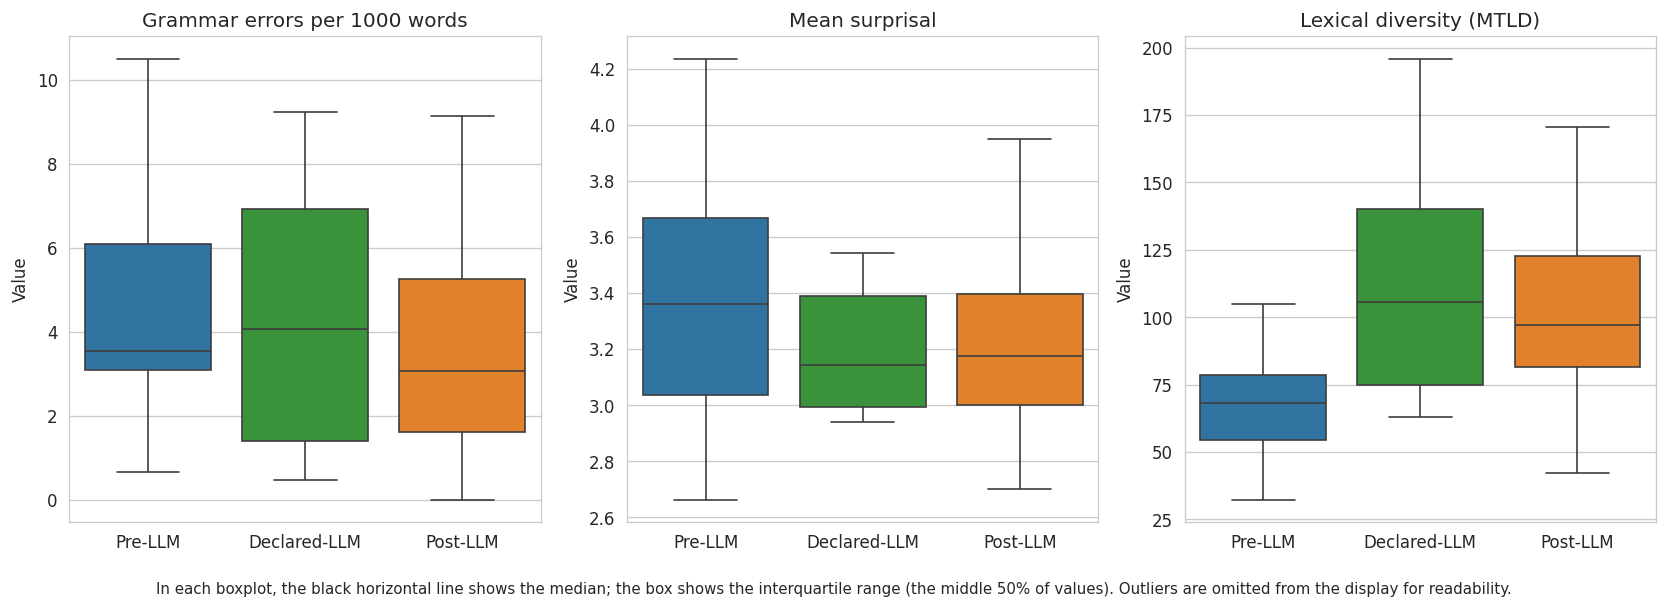

In [12]:
# ============================================================
# CELL 12: FIGURE 1
# Three-panel figure for the strongest results:
# - Grammar errors
# - Mean surprisal
# - Lexical diversity (MTLD)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

sns.boxplot(
    data=df_plot,
    x="corpus_group_label",
    y="grammar_errors_per_1000",
    hue="corpus_group_label",
    order=LABEL_ORDER,
    hue_order=LABEL_ORDER,
    palette=GROUP_PALETTE,
    showfliers=False,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Grammar errors per 1000 words")
axes[0].set_xlabel("")
axes[0].set_ylabel("Value")

sns.boxplot(
    data=df_plot,
    x="corpus_group_label",
    y="mean_surprisal",
    hue="corpus_group_label",
    order=LABEL_ORDER,
    hue_order=LABEL_ORDER,
    palette=GROUP_PALETTE,
    showfliers=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Mean surprisal")
axes[1].set_xlabel("")
axes[1].set_ylabel("Value")

sns.boxplot(
    data=df_plot,
    x="corpus_group_label",
    y="lexical_diversity_mtld",
    hue="corpus_group_label",
    order=LABEL_ORDER,
    hue_order=LABEL_ORDER,
    palette=GROUP_PALETTE,
    showfliers=False,
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Lexical diversity (MTLD)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Value")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)

fig.text(
    0.5, -0.02,
    "In each boxplot, the black horizontal line shows the median; the box shows the interquartile range (the middle 50% of values). Outliers are omitted from the display for readability.",
    ha="center",
    va="top",
    fontsize=9
)

plt.tight_layout()
plt.show()

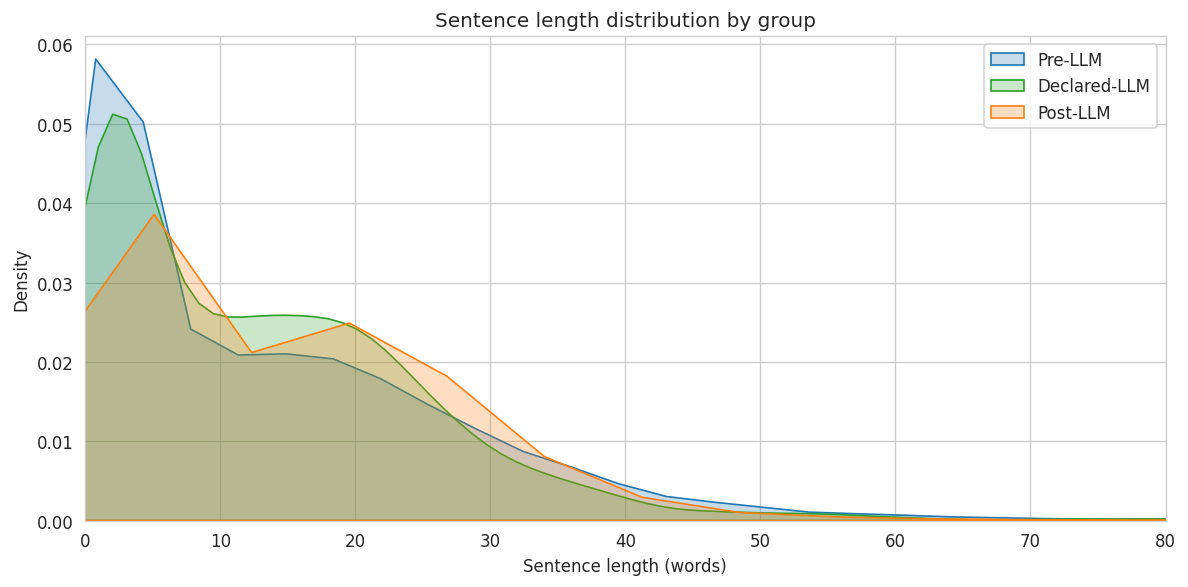

In [13]:
# ============================================================
# CELL 13: FIGURE 2
# Sentence-length density plot
# ============================================================

plt.figure(figsize=(10, 5))

for group in GROUP_ORDER:
    lengths = []
    subset = df_all[df_all["corpus_group"] == group]

    for _, row in subset.iterrows():
        lengths.extend(row["sentence_lengths"])

    sns.kdeplot(
        lengths,
        label=GROUP_LABELS[group],
        fill=True,
        alpha=0.25,
        color=GROUP_PALETTE[GROUP_LABELS[group]]
    )

plt.xlim(0, 80)
plt.title("Sentence length distribution by group")
plt.xlabel("Sentence length (words)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

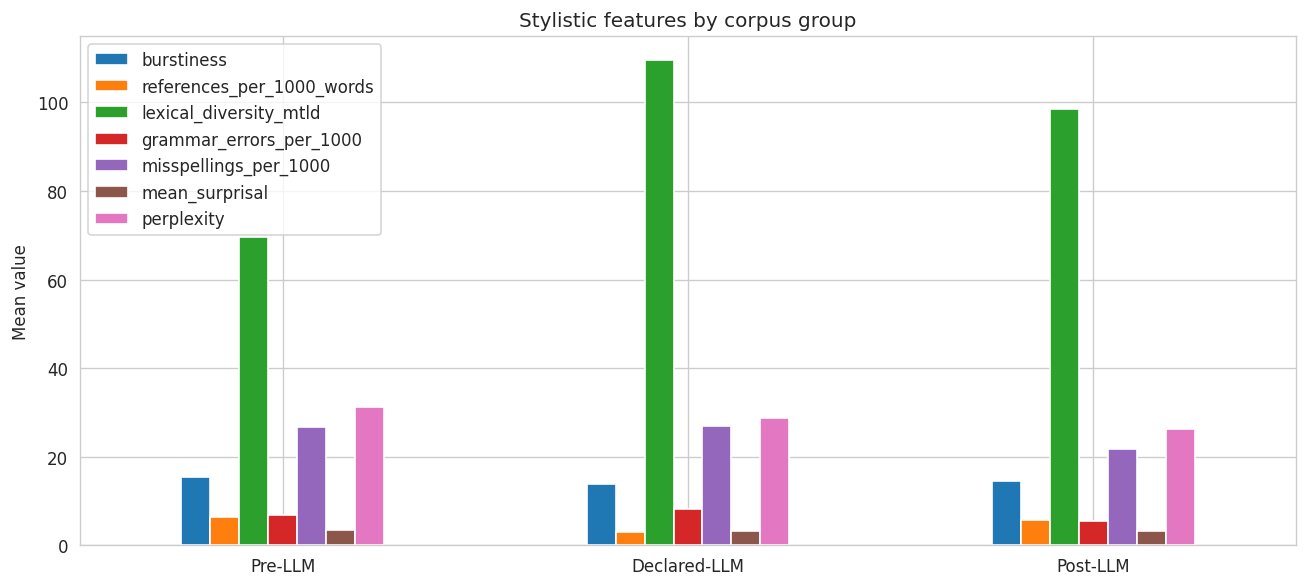

In [14]:
# ============================================================
# CELL 14: FIGURE 3
# Stylistic features by corpus group
# ============================================================

plot_vars = [
    "burstiness",
    "references_per_1000_words",
    "lexical_diversity_mtld",
    "grammar_errors_per_1000",
    "misspellings_per_1000",
    "mean_surprisal",
    "perplexity"
]

group_summary_plot = (
    df_all.groupby("corpus_group")[plot_vars]
    .mean()
    .reindex(GROUP_ORDER)
)

group_summary_plot.index = [GROUP_LABELS[g] for g in group_summary_plot.index]

ax = group_summary_plot.plot(kind="bar", figsize=(11, 5))
ax.set_title("Stylistic features by corpus group")
ax.set_ylabel("Mean value")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

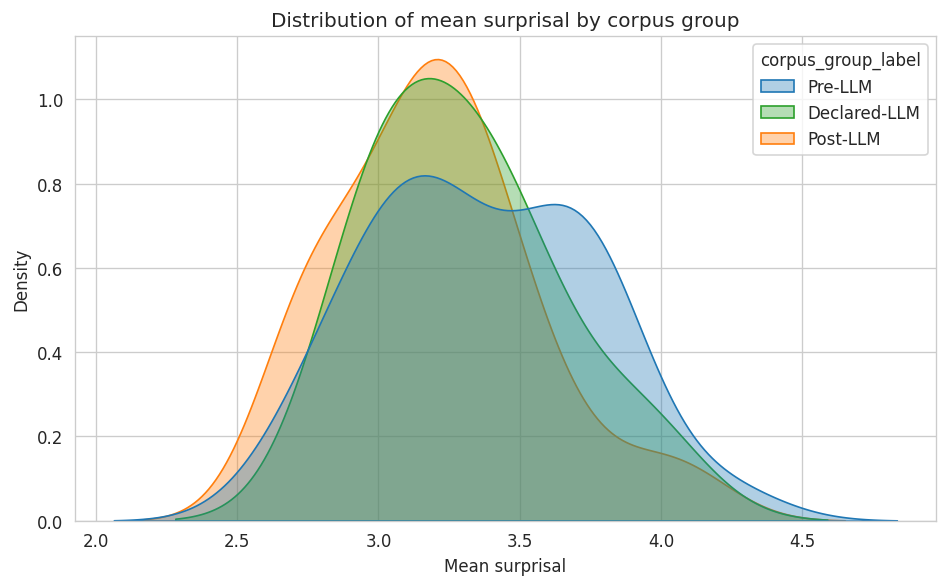

In [15]:
# ============================================================
# CELL 15: FIGURE 4
# Distribution of mean surprisal by corpus group
# ============================================================

plot_df2 = df_all.copy()
plot_df2["corpus_group_label"] = plot_df2["corpus_group"].map(GROUP_LABELS)

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=plot_df2,
    x="mean_surprisal",
    hue="corpus_group_label",
    hue_order=LABEL_ORDER,
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette=GROUP_PALETTE
)

plt.title("Distribution of mean surprisal by corpus group")
plt.xlabel("Mean surprisal")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

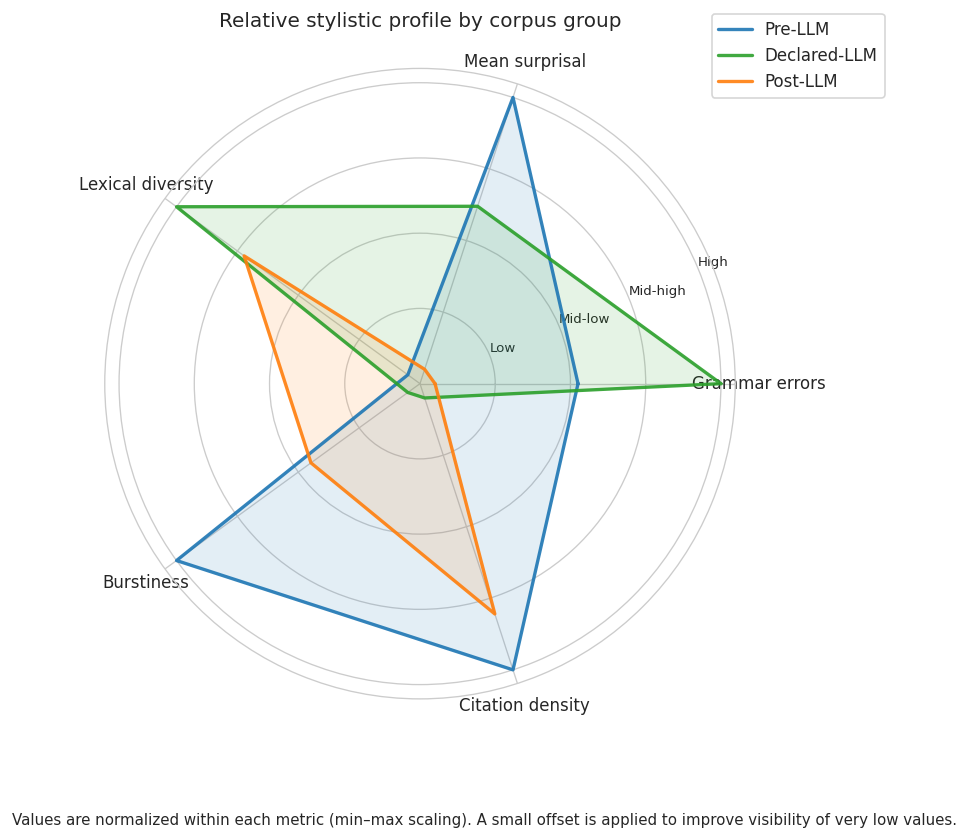

In [16]:
# ============================================================
# CELL 16: FIGURE 5
# Radar chart of five core metrics
#
# Examiner note:
# Values are normalized within each metric using min–max scaling.
# This allows metrics measured on different numerical scales to be
# compared visually within a single radar chart.
# ============================================================

metrics = [
    "grammar_errors_per_1000",
    "mean_surprisal",
    "lexical_diversity_mtld",
    "burstiness",
    "references_per_1000_words"
]

metric_labels = [
    "Grammar errors",
    "Mean surprisal",
    "Lexical diversity",
    "Burstiness",
    "Citation density"
]

radar_df = (
    df_all.groupby("corpus_group")[metrics]
    .mean()
    .reindex(GROUP_ORDER)
)

radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

# small offset so minimum values remain visible
epsilon = 0.05
radar_norm = radar_norm.clip(lower=epsilon)

N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for group in GROUP_ORDER:
    values = radar_norm.loc[group].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        color=GROUP_PALETTE[GROUP_LABELS[group]],
        linewidth=2,
        label=GROUP_LABELS[group],
        alpha=0.9
    )
    ax.fill(
        angles,
        values,
        color=GROUP_PALETTE[GROUP_LABELS[group]],
        alpha=0.12
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=10)

ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["Low", "Mid-low", "Mid-high", "High"], fontsize=8)

ax.set_title("Relative stylistic profile by corpus group", pad=25)

fig.text(
    0.5, -0.05,
    "Values are normalized within each metric (min–max scaling). A small offset is applied to improve visibility of very low values.",
    ha="center",
    fontsize=9
)

ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# CELL 17: HIGH-RES EXPORT TO GOOGLE DRIVE
# Purpose:
# - save the selected figures as both PDF and PNG
# - save tables as CSV
#
# The export path can be modified if a different storage location
# is required.
# ============================================================

EXPORT_DIR = "/content/drive/MyDrive/papers/exports_final"
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_current_figure(name):
    pdf_path = os.path.join(EXPORT_DIR, f"{name}.pdf")
    png_path = os.path.join(EXPORT_DIR, f"{name}.png")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.savefig(png_path, dpi=600, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")


# -------- Export Figure 1 --------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

sns.boxplot(
    data=df_plot,
    x="corpus_group_label",
    y="grammar_errors_per_1000",
    hue="corpus_group_label",
    order=LABEL_ORDER,
    hue_order=LABEL_ORDER,
    palette=GROUP_PALETTE,
    showfliers=False,
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Grammar errors per 1000 words")
axes[0].set_xlabel("")
axes[0].set_ylabel("Value")

sns.boxplot(
    data=df_plot,
    x="corpus_group_label",
    y="mean_surprisal",
    hue="corpus_group_label",
    order=LABEL_ORDER,
    hue_order=LABEL_ORDER,
    palette=GROUP_PALETTE,
    showfliers=False,
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Mean surprisal")
axes[1].set_xlabel("")
axes[1].set_ylabel("Value")

sns.boxplot(
    data=df_plot,
    x="corpus_group_label",
    y="lexical_diversity_mtld",
    hue="corpus_group_label",
    order=LABEL_ORDER,
    hue_order=LABEL_ORDER,
    palette=GROUP_PALETTE,
    showfliers=False,
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Lexical diversity (MTLD)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Value")

for ax in axes:
    ax.tick_params(axis="x", rotation=0)

fig.text(
    0.5, -0.02,
    "In each boxplot, the black horizontal line shows the median; the box shows the interquartile range (the middle 50% of values). Outliers are omitted from the display for readability.",
    ha="center",
    va="top",
    fontsize=9
)

plt.tight_layout()
save_current_figure("01_three_panel_core_results")
plt.close()

# -------- Export Figure 2 --------
plt.figure(figsize=(10, 5))

for group in GROUP_ORDER:
    lengths = []
    subset = df_all[df_all["corpus_group"] == group]

    for _, row in subset.iterrows():
        lengths.extend(row["sentence_lengths"])

    sns.kdeplot(
        lengths,
        label=GROUP_LABELS[group],
        fill=True,
        alpha=0.25,
        color=GROUP_PALETTE[GROUP_LABELS[group]]
    )

plt.xlim(0, 80)
plt.title("Sentence length distribution by group")
plt.xlabel("Sentence length (words)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
save_current_figure("02_sentence_length_distribution")
plt.close()

# -------- Export Figure 3 --------
group_summary_plot = (
    df_all.groupby("corpus_group")[plot_vars]
    .mean()
    .reindex(GROUP_ORDER)
)

group_summary_plot.index = [GROUP_LABELS[g] for g in group_summary_plot.index]

ax = group_summary_plot.plot(kind="bar", figsize=(11, 5))
ax.set_title("Stylistic features by corpus group")
ax.set_ylabel("Mean value")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
save_current_figure("03_stylistic_features_by_group")
plt.close()

# -------- Export Figure 4 --------
plot_df2 = df_all.copy()
plot_df2["corpus_group_label"] = plot_df2["corpus_group"].map(GROUP_LABELS)

plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=plot_df2,
    x="mean_surprisal",
    hue="corpus_group_label",
    hue_order=LABEL_ORDER,
    fill=True,
    common_norm=False,
    alpha=0.35,
    palette=GROUP_PALETTE
)

plt.title("Distribution of mean surprisal by corpus group")
plt.xlabel("Mean surprisal")
plt.ylabel("Density")
plt.tight_layout()
save_current_figure("04_mean_surprisal_distribution")
plt.close()

# -------- Export Figure 5 --------
radar_df = (
    df_all.groupby("corpus_group")[metrics]
    .mean()
    .reindex(GROUP_ORDER)
)

radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())
radar_norm = radar_norm.clip(lower=0.05)

N = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for group in GROUP_ORDER:
    values = radar_norm.loc[group].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        color=GROUP_PALETTE[GROUP_LABELS[group]],
        linewidth=2,
        label=GROUP_LABELS[group],
        alpha=0.9
    )
    ax.fill(
        angles,
        values,
        color=GROUP_PALETTE[GROUP_LABELS[group]],
        alpha=0.12
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_labels, fontsize=10)

ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["Low", "Mid-low", "Mid-high", "High"], fontsize=8)

ax.set_title("Relative stylistic profile by corpus group", pad=25)

fig.text(
    0.5, -0.05,
    "Values are normalized within each metric (min–max scaling). A small offset is applied to improve visibility of very low values.",
    ha="center",
    fontsize=9
)

ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.10))

plt.tight_layout()
save_current_figure("05_radar_chart_stylistic_profile")
plt.close()

# -------- Export tables --------
corpus_overview.to_csv(os.path.join(EXPORT_DIR, "table_corpus_overview.csv"))
group_summary.to_csv(os.path.join(EXPORT_DIR, "table_summary_table.csv"))
results_df.to_csv(os.path.join(EXPORT_DIR, "table_t_test_results.csv"), index=False)

print(f"\nAll figures and tables exported to: {EXPORT_DIR}")

Saved: /content/drive/MyDrive/papers/exports_final/01_three_panel_core_results.pdf
Saved: /content/drive/MyDrive/papers/exports_final/01_three_panel_core_results.png
Saved: /content/drive/MyDrive/papers/exports_final/02_sentence_length_distribution.pdf
Saved: /content/drive/MyDrive/papers/exports_final/02_sentence_length_distribution.png
Saved: /content/drive/MyDrive/papers/exports_final/03_stylistic_features_by_group.pdf
Saved: /content/drive/MyDrive/papers/exports_final/03_stylistic_features_by_group.png
Saved: /content/drive/MyDrive/papers/exports_final/04_mean_surprisal_distribution.pdf
Saved: /content/drive/MyDrive/papers/exports_final/04_mean_surprisal_distribution.png
Saved: /content/drive/MyDrive/papers/exports_final/05_radar_chart_stylistic_profile.pdf
Saved: /content/drive/MyDrive/papers/exports_final/05_radar_chart_stylistic_profile.png

All figures and tables exported to: /content/drive/MyDrive/papers/exports_final
